ARTI308 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

![step2.png](img/step2.png)

In this lab, we will apply practical preprocessing techniques step by step.

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Load Dataset

In [ ]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("Chocolate_Sales.csv")
df.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184
5,Van Tuxwell,India,Smooth Sliky Salty,06/06/2022,"$5,376.00",38
6,Oby Sorrel,UK,99% Dark & Pure,25/01/2022,"$13,685.00",176
7,Gunar Cockshoot,Australia,After Nines,24/03/2022,"$3,080.00",73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,20/04/2022,"$3,990.00",59
9,Brien Boise,Australia,99% Dark & Pure,04/07/2022,"$2,835.00",102


## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.
For example:
- `Date` should be datetime
- `Revenue` should be numeric

In [ ]:
df.dtypes

Sales Person       str
Country            str
Product            str
Date               str
Amount             str
Boxes Shipped    int64
dtype: object

We observe that some columns are stored as object type.
`Date` and `Amount` may not yet be in the correct format.
Incorrect data types can prevent proper calculations and time-based analysis.

### 2.2 Convert Incorrect Data Types
We will convert:
- `Date` to datetime format
- `Amount` to numeric after removing currency symbols

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True)
df['Amount'] = pd.to_numeric(df['Amount'])

df.dtypes

Sales Person                str
Country                     str
Product                     str
Date             datetime64[us]
Amount                  float64
Boxes Shipped             int64
dtype: object

Now `Date` is correctly stored as *datetime64*.
`Amount` is now numeric *(float64)*.
This allows us to perform time-based grouping and numerical calculations correctly.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [ ]:
df.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

The output shows whether any column contains missing values.
If all values are zero, the dataset is complete.
If any column contains missing values, we must handle them.

### 3.2 Demonstration: Introduce Artificial Missing Values
### Why?

Since our dataset has no missing values, we introduce artificial ones *for learning purposes*.

we will be running this line:

`df_missing.loc[0:5, 'Amount'] = np.nan`


- `df_missing`: The pandas DataFrame you are modifying.

- `.loc[0:5, 'Amount']`: This uses the label-based indexer to select specific rows and columns.

- `0:5`: Selects rows with index labels 0, 1, 2, 3, 4, and 5. In label-based indexing, the end index is inclusive.

- `'Amount'`: Selects the column named 'Amount'.

- `= np.nan`: Assigns the value np.nan (which stands for "Not a Number") to all the selected cells. This is the standard way to represent missing or null values in numerical columns in pandas. The column's data type will be converted to float

In [ ]:
df_missing = df.copy()
df_missing.loc[0:5, 'Amount'] = np.nan
df_missing.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           6
Boxes Shipped    0
dtype: int64

Now the Amount column contains missing values.

In [ ]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (3282, 6)
After removing some values:  (3282, 6)


In [ ]:
df_missing.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,NaN,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,NaN,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,NaN,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,NaN,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,NaN,184
5,Van Tuxwell,India,Smooth Sliky Salty,2022-06-06,NaN,38
6,Oby Sorrel,UK,99% Dark & Pure,2022-01-25,13685.0,176
7,Gunar Cockshoot,Australia,After Nines,2022-03-24,3080.0,73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,2022-04-20,3990.0,59
9,Brien Boise,Australia,99% Dark & Pure,2022-07-04,2835.0,102


### Strategy 1: Remove Records
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

In [ ]:
df_removed = df_missing.dropna()
df_removed.shape

(3276, 6)

In [ ]:
df_removed.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

The dataset now has fewer rows.
If only a small portion of data was missing, this method is acceptable.

However, removing too many rows can reduce model performance.

### Strategy 2: Mean Imputation

![Mean.png](img\Mean.png)

The mean represents the average value.
It is commonly used for normally distributed data.

In [ ]:
df_missing.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,NaN,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,NaN,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,NaN,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,NaN,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,NaN,184
5,Van Tuxwell,India,Smooth Sliky Salty,2022-06-06,NaN,38
6,Oby Sorrel,UK,99% Dark & Pure,2022-01-25,13685.0,176
7,Gunar Cockshoot,Australia,After Nines,2022-03-24,3080.0,73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,2022-04-20,3990.0,59
9,Brien Boise,Australia,99% Dark & Pure,2022-07-04,2835.0,102


In [ ]:
df_imputed_mean = df_missing.copy()

mean_value = df_imputed_mean['Amount'].mean()
df_imputed_mean['Amount'] = df_imputed_mean['Amount'].fillna(mean_value)

df_imputed_mean.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [ ]:
df_imputed_mean.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,6026.272241,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,6026.272241,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,6026.272241,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,6026.272241,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,6026.272241,184
5,Van Tuxwell,India,Smooth Sliky Salty,2022-06-06,6026.272241,38
6,Oby Sorrel,UK,99% Dark & Pure,2022-01-25,13685.000000,176
7,Gunar Cockshoot,Australia,After Nines,2022-03-24,3080.000000,73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,2022-04-20,3990.000000,59
9,Brien Boise,Australia,99% Dark & Pure,2022-07-04,2835.000000,102


Missing values are now replaced with the average revenue.
This preserves dataset size but may reduce variability.
Mean imputation is sensitive to outliers.

### Strategy 3: Median Imputation

![median_formula_2.png](img/median_formula_2.png)
The median is more robust to outliers than the mean.
It is preferred for skewed data.

In [ ]:
df_imputed_median = df_missing.copy()

median_value = df_imputed_median['Amount'].median()
df_imputed_median['Amount'] = df_imputed_median['Amount'].fillna(median_value)

df_imputed_median.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [ ]:
df_imputed_median.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5220.745,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,5220.745,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,5220.745,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,5220.745,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,5220.745,184
5,Van Tuxwell,India,Smooth Sliky Salty,2022-06-06,5220.745,38
6,Oby Sorrel,UK,99% Dark & Pure,2022-01-25,13685.000,176
7,Gunar Cockshoot,Australia,After Nines,2022-03-24,3080.000,73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,2022-04-20,3990.000,59
9,Brien Boise,Australia,99% Dark & Pure,2022-07-04,2835.000,102


Missing values are replaced with the middle value.
This approach is safer when data contains extreme values.

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using the IQR method.

![IQR.png](img/IQR.png)

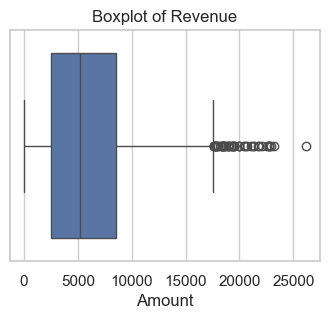

In [ ]:
plt.figure(figsize=(4,3))
sns.boxplot(x=df['Amount'])
plt.title("Boxplot of Revenue")
plt.show()

Points outside the whiskers represent potential outliers.
These extreme revenue values may influence model predictions.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [ ]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]
outliers.head(15)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
66,Van Tuxwell,Australia,Organic Choco Syrup,2022-08-10,19453.00,14
135,Van Tuxwell,India,Organic Choco Syrup,2022-05-16,19929.00,174
212,Marney O'Breen,UK,Smooth Sliky Salty,2022-05-13,18991.00,88
434,Jan Morforth,New Zealand,Mint Chip Choco,2022-06-30,18340.00,285
543,Ches Bonnell,India,Peanut Butter Cubes,2022-01-27,22050.00,208
589,Curtice Advani,India,Smooth Sliky Salty,2022-04-19,19327.00,135
609,Jan Morforth,Australia,Mint Chip Choco,2022-02-22,17626.00,103
751,Rafaelita Blaksland,New Zealand,Eclairs,2022-02-07,19481.00,51
806,Brien Boise,India,85% Dark Bars,2022-08-09,18032.00,205
1008,Kaine Padly,UK,After Nines,2022-01-21,18697.00,176


The output displays records considered extreme based on statistical boundaries.
These may be valid high-value transactions or potential data errors.

### Remove Outliers
We remove values outside the acceptable range.

In [ ]:
df_no_outliers = df[(df['Amount'] >= lower) & (df['Amount'] <= upper)]
print("Original shape: ",df.shape)
print("After removing outliers: ",df_no_outliers.shape)

Original shape:  (3282, 6)
After removing outliers:  (3232, 6)


The dataset size is slightly reduced.
Removing outliers reduces distortion but may also remove important rare events.

#### Important Note on Removing Outliers

Not all outliers are errors.

Some extreme values may represent rare but important real-world events.  
For example, in a sales dataset, a very large transaction might correspond to a bulk corporate order or a seasonal promotion.  

If we remove such values blindly, we may lose valuable information and bias the analysis.

Before removing outliers, we should always ask:
- Is this value a data entry mistake?
- Or is it a valid but rare observation?

### Capping Outliers (Percentile Method)
Instead of removing outliers, we replace extreme values with percentile limits.

![percentile.png](img/percentile.png)

In [ ]:
lower_cap = df['Amount'].quantile(0.05)
upper_cap = df['Amount'].quantile(0.95)

df_capped = df.copy()
df_capped['Amount'] = df_capped['Amount'].clip(lower_cap, upper_cap)

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.

It works using the formula:
![min_max.png](img/min_max.png)

This method preserves the original distribution shape and relative ordering of values.

Min-Max normalization is especially useful for distance-based models such as:
- K-Nearest Neighbors (KNN)
- K-Means clustering
- Support Vector Machines (SVM)

These models rely on distance calculations, and if features are on very different scales, one feature can dominate the distance computation.

In [ ]:
df[['Amount', 'Boxes Shipped']].head()

,Amount,Boxes Shipped
0,5320.0,180
1,7896.0,94
2,4501.0,91
3,12726.0,342
4,13685.0,184


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Amount', 'Boxes Shipped']].copy()

df_scaled[['Amount', 'Boxes Shipped']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Amount,Boxes Shipped
0,0.203066,0.230373
1,0.301522,0.119691
2,0.171763,0.115830
3,0.486127,0.438867
4,0.522780,0.235521


After applying Min-Max normalization, all numerical values are scaled to the range between 0 and 1.

The smallest value in each feature becomes 0, and the largest becomes 1.
All other values are proportionally mapped between these two limits.

Importantly, normalization does NOT change the relative relationships between data points.
If one transaction originally had higher revenue than another, it will still have a higher normalized value.

### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

This is done by subtracting the mean and dividing by the standard deviation:

![zscore.png](img/zscore.png)

This method keeps the shape of the distribution but rescales it around zero.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['Amount', 'Boxes Shipped']].copy()

df_standardized[['Amount', 'Boxes Shipped']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Amount,Boxes Shipped
0,-0.161686,0.123648
1,0.424660,-0.569868
2,-0.348106,-0.594061
3,1.524058,1.430038
4,1.742345,0.155904


After standardization, the numerical features are centered around 0.
Values above the original mean become **positive**, and values below the mean become **negative**.

The standard deviation of each feature becomes approximately 1, meaning the spread of the data is standardized.

This transformation is especially useful for:
- Linear regression
- Support Vector Machines (SVM)
- PCA

Because these models assume features are centered and scaled similarly.

## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)

In such cases, dimensionality reduction using PCA is meaningful
because we can combine correlated features into fewer components.

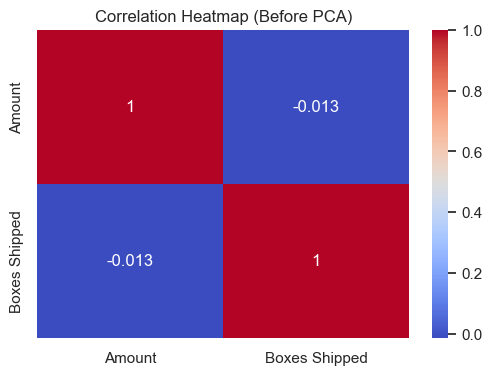

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Amount','Boxes Shipped']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

The heatmap shows the correlation between the numerical features:

- The diagonal values are 1 because each feature is perfectly correlated with itself.
- The correlation between `Amount` and `Boxes Shipped` is approximately *-0.013*.

A correlation value close to 0 indicates that there is almost **NO linear** relationship between the two features.

This means that `Amount` and `Boxes Shipped` do not move together in a predictable linear pattern.

Since PCA is most useful when features are strongly correlated,
the benefit of dimensionality reduction in this case may be limited.

Therefore, applying PCA here is mainly for demonstration purposes rather than necessity.

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:

- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance, while being orthogonal (perpendicular) to PC1.

This allows us to reduce dimensionality while retaining most of the important information in the data.

### Visual Intuition

Imagine we have two features:

X1 = Amount  
X2 = Boxes Shipped  

If we plot the data points, they may look like this:

              X2
               |
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1

Notice that the points follow a diagonal pattern.
This means the two features are correlated and contain overlapping information.

Instead of keeping both X1 and X2 separately,
PCA finds the direction where the data varies the most.

That direction becomes **Principal Component 1 (PC1)**.

              X2
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1
                    \
                     \
                      \
                       \
                        → PC1 (maximum variance direction)

PC2 is the direction perpendicular to PC1.

If most of the variation is along PC1,
then PC1 alone captures most of the dataset’s information.

In that case, we can reduce:

2 features → 1 feature (PC1)

while keeping most of the variance.

In [ ]:
from sklearn.decomposition import PCA

X = df_standardized[['Amount', 'Boxes Shipped']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.50657693 0.49342307]


The `Explained Variance Ratio` indicates how much of the total information (variance) is captured by each principal component.

For example:
- If PC1 explains 85% of the variance, it means that one new feature already summarizes most of the dataset's information.
- If PC1 and PC2 together explain nearly 100%, then very little information is lost.

When most of the variance is captured by fewer components, dimensionality reduction is considered effective.

This helps simplify models, reduce computational cost, and sometimes improve generalization performance.

In [ ]:
# # In addition to the heatmap, we can visualize the relationship between two features using a scatter plot.
# # A scatter plot allows us to observe whether the features exhibit a linear pattern, meaning whether they increase or decrease together in a consistent way.


# plt.figure(figsize=(6,4))
# plt.scatter(df_standardized['Amount'], df_standardized['Boxes Shipped'])
# plt.xlabel("Amount (Standardized)")
# plt.ylabel("Boxes Shipped (Standardized)")
# plt.title("Scatter Plot: Amount vs Boxes Shipped")
# plt.show()

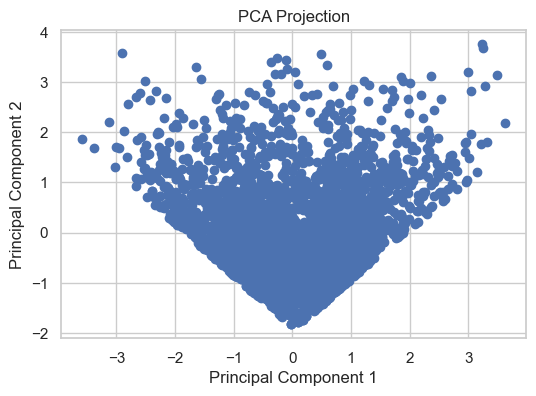

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Each point in this plot represents one sales transaction.

The axes no longer represent the original features (Amount and Boxes Shipped).
Instead:

- The horizontal axis represents Principal Component 1 (PC1).
- The vertical axis represents Principal Component 2 (PC2).

PC1 captures the direction of maximum variance in the data.
PC2 captures the second most important direction, perpendicular to PC1.

The spread of points along the horizontal direction indicates how much variation is captured by PC1.
If most of the spread appears horizontally, it suggests that PC1 captures most of the dataset's information.

This projection allows us to visualize high-dimensional data in a lower-dimensional space.

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of Assignment 2

Imports & Load Dataset

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

# Load the Student Mental Health dataset
df = pd.read_csv("/content/Student Mental health.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (101, 11)


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


Task 1: Identify Data Quality Issues

In [4]:
# ─────────────────────────────────────────────
# Task 1: Identify Data Quality Issues
# ─────────────────────────────────────────────

print("=" * 55)
print("TASK 1: DATA QUALITY ASSESSMENT")
print("=" * 55)

# 1. Shape
print(f"\n📐 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# 2. Data types
print("\n📋 Column Data Types:")
print(df.dtypes)

# 3. Missing values
print("\n❓ Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_df[missing_df["Missing Count"] > 0])
print(f"\nTotal missing values: {missing.sum()}")

# 4. Duplicate rows
print(f"\n🔁 Duplicate Rows: {df.duplicated().sum()}")

# 5. Unique values for categorical columns
print("\n🔤 Unique Values in Categorical Columns:")
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"  {col}: {df[col].unique()}")

# 6. Basic stats for numerical columns
print("\n📊 Descriptive Statistics (Numerical Columns):")
print(df.describe())

TASK 1: DATA QUALITY ASSESSMENT

📐 Dataset Shape: 101 rows × 11 columns

📋 Column Data Types:
Timestamp                                        object
Choose your gender                               object
Age                                             float64
What is your course?                             object
Your current year of Study                       object
What is your CGPA?                               object
Marital status                                   object
Do you have Depression?                          object
Do you have Anxiety?                             object
Do you have Panic attack?                        object
Did you seek any specialist for a treatment?     object
dtype: object

❓ Missing Values per Column:
     Missing Count  Missing %
Age              1   0.990099

Total missing values: 1

🔁 Duplicate Rows: 0

🔤 Unique Values in Categorical Columns:
  Timestamp: ['8/7/2020 12:02' '8/7/2020 12:04' '8/7/2020 12:05' '8/7/2020 12:06'
 '8/7/2020 12:13'

### 📝 Task 1 — Summary of Data Quality Issues Found

Based on the data quality assessment, the following issues were identified:

| # | Issue | Details |
|---|-------|---------|
| 1 | **Missing Values** | `Age` column has **1 missing value** (0.99% of data) — all other columns are complete |
| 2 | **Inconsistent Timestamp Format** | The `Timestamp` column uses two different formats: `8/7/2020 12:02` (no seconds) and `13/07/2020 10:07:32` (with seconds, different date order) |
| 3 | **Inconsistent Course Names** | The `What is your course?` column has many spelling variations for the same course, e.g. `"Engineering"`, `"Engine"`, `"engin"` / `"Kirkhs"`, `"KIRKHS"`, `"Irkhs"` / `"Pendidikan islam"`, `"Pendidikan Islam"`, `"Pendidikan Islam "` |
| 4 | **Inconsistent Year of Study Casing** | Values like `"year 1"` and `"Year 1"` represent the same category but are treated as different labels |
| 5 | **Trailing Whitespace in Values** | Several values have trailing spaces, e.g. `"Accounting "`, `"Nursing "`, `"3.50 - 4.00 "` — these would be treated as different categories |
| 6 | **No Duplicate Rows** | No exact duplicate records were found |
| 7 | **Timestamp Not Useful for ML** | The `Timestamp` column records survey submission time and carries no predictive value — it should be dropped before modeling |
| 8 | **Limited Numerical Features** | Only `Age` is truly numerical. `CGPA` is stored as a text range (e.g. `"3.00 - 3.49"`) and must be encoded before any numerical analysis |

Task 2: Handle Missing Values

In [6]:
# ─────────────────────────────────────────────
# Task 2: Apply One Missing Value Strategy
# ─────────────────────────────────────────────

print("=" * 55)
print("TASK 2: MISSING VALUE HANDLING")
print("=" * 55)

# Check missing values before
print("\nMissing values BEFORE:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Strategy: Fill missing Age values with the MEDIAN
# Reason: Age is a numerical column and its distribution may be skewed
# by outliers (e.g., unusually old students). The median is more robust
# than the mean for skewed distributions and is a standard choice for age.

median_age = df["Age"].median()
print(f"\nMedian Age used for imputation: {median_age}")

df["Age"].fillna(median_age, inplace=True)

# Check missing values after
print("\nMissing values AFTER:")
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else "✅ No missing values remaining.")

print("\nStrategy Used: Median Imputation for Age")
print("   Reason: The median is resistant to outliers, making it a")
print("   better central tendency measure for a small dataset (n=101)")
print("   where a few extreme ages could distort the mean.")

TASK 2: MISSING VALUE HANDLING

Missing values BEFORE:
Series([], dtype: int64)

Median Age used for imputation: 19.0

Missing values AFTER:
✅ No missing values remaining.

Strategy Used: Median Imputation for Age
   Reason: The median is resistant to outliers, making it a
   better central tendency measure for a small dataset (n=101)
   where a few extreme ages could distort the mean.


/tmp/ipykernel_5610/3830871131.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(median_age, inplace=True)


Task 3: Detect & Handle Outliers Using IQR

TASK 3: OUTLIER DETECTION & HANDLING (IQR METHOD)

IQR Analysis for 'Age':
   Q1           = 18.0
   Q3           = 23.0
   IQR          = 5.0
   Lower Bound  = 10.5
   Upper Bound  = 30.5

Outliers detected: 0 rows
Empty DataFrame
Columns: [Age]
Index: []


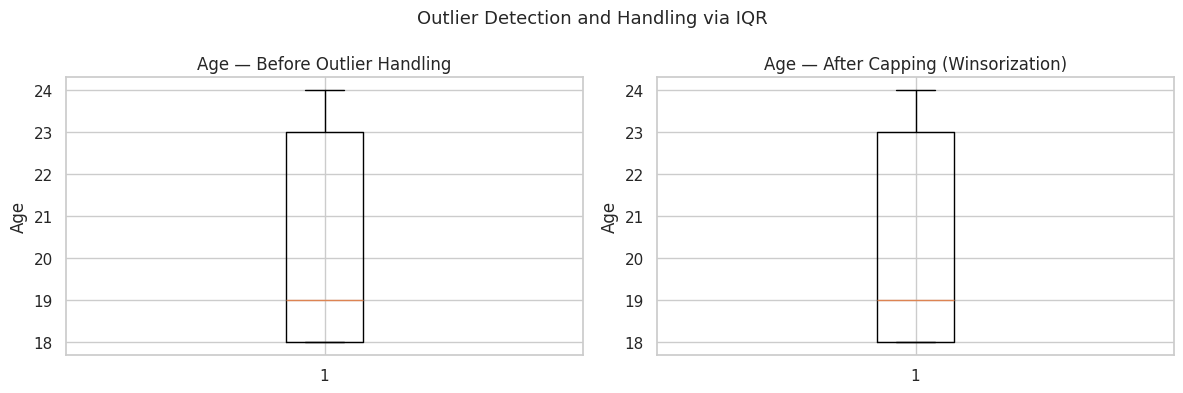


✅ Outlier handling complete using Capping (Winsorization).
   Values outside [lower, upper] bounds were clipped to the boundary.
   This preserves all rows while eliminating extreme values.


In [7]:
# ─────────────────────────────────────────────
# Task 3: Detect and Handle Outliers Using IQR
# ─────────────────────────────────────────────

print("=" * 55)
print("TASK 3: OUTLIER DETECTION & HANDLING (IQR METHOD)")
print("=" * 55)

# Age is the only true numerical column
col = "Age"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nIQR Analysis for '{col}':")
print(f"   Q1           = {Q1}")
print(f"   Q3           = {Q3}")
print(f"   IQR          = {IQR}")
print(f"   Lower Bound  = {lower_bound}")
print(f"   Upper Bound  = {upper_bound}")

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print(f"\nOutliers detected: {len(outliers)} rows")
print(outliers[[col]])

# Visualize before capping
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df[col].dropna())
axes[0].set_title("Age — Before Outlier Handling")
axes[0].set_ylabel("Age")

# Handle outliers: Capping (Winsorization)
# Values below lower bound → set to lower bound
# Values above upper bound → set to upper bound
df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

axes[1].boxplot(df[col].dropna())
axes[1].set_title("Age — After Capping (Winsorization)")
axes[1].set_ylabel("Age")

plt.suptitle("Outlier Detection and Handling via IQR", fontsize=13)
plt.tight_layout()
plt.show()

print("\n✅ Outlier handling complete using Capping (Winsorization).")
print("   Values outside [lower, upper] bounds were clipped to the boundary.")
print("   This preserves all rows while eliminating extreme values.")

Task 4: Normalize Numerical Features


TASK 4: NORMALIZATION

Numerical features selected: ['Age', 'CGPA_numeric']

Original values (first 5 rows):
    Age  CGPA_numeric
0  18.0          3.25
1  21.0          3.25
2  19.0          3.25
3  22.0          3.25
4  23.0          3.25

Min-Max Normalized (first 5 rows):
   Age_MinMax  CGPA_MinMax
0    0.000000     0.818182
1    0.500000     0.818182
2    0.166667     0.818182
3    0.666667     0.818182
4    0.833333     0.818182
   Range check — Age: [0.00, 1.00]
   Range check — CGPA: [0.00, 1.00]

Z-score Standardized (first 5 rows):
   Age_Zscore  CGPA_Zscore
0   -1.015659    -0.179422
1    0.195934    -0.179422
2   -0.611794    -0.179422
3    0.599799    -0.179422
4    1.003663    -0.179422
   Mean — Age: -0.0000, Std: 1.0050
   Mean — CGPA: -0.0000, Std: 1.0050


/tmp/ipykernel_5610/4027693171.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["CGPA_numeric"].fillna(df["CGPA_numeric"].median(), inplace=True)


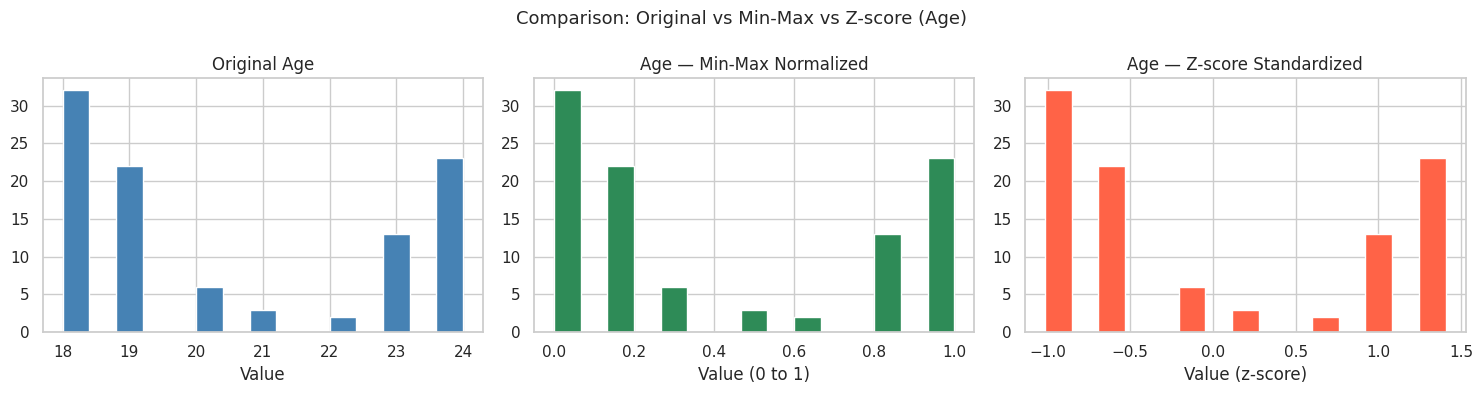


✅ Normalization complete.
   Min-Max: Scales values to [0, 1] — useful for distance-based models.
   Z-score: Centers mean=0, std=1 — useful for models sensitive to scale.


In [8]:
# ─────────────────────────────────────────────
# Task 4: Normalize Numerical Features
#         Min-Max Normalization & Z-score Standardization
# ─────────────────────────────────────────────

print("=" * 55)
print("TASK 4: NORMALIZATION")
print("=" * 55)

# Encode CGPA as ordinal numerical (midpoint of range)
cgpa_map = {
    "0 - 1.99": 1.0,
    "2.00 - 2.49": 2.25,
    "2.50 - 2.99": 2.75,
    "3.00 - 3.49": 3.25,
    "3.50 - 4.00": 3.75
}
df["CGPA_numeric"] = df["What is your CGPA?"].map(cgpa_map)

# Fill any unmapped CGPA with median
df["CGPA_numeric"].fillna(df["CGPA_numeric"].median(), inplace=True)

numerical_features = df[["Age", "CGPA_numeric"]].copy()
print(f"\nNumerical features selected: {list(numerical_features.columns)}")
print("\nOriginal values (first 5 rows):")
print(numerical_features.head())

# ── Min-Max Normalization ──────────────────────
minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(numerical_features)
df_minmax = pd.DataFrame(minmax_scaled, columns=["Age_MinMax", "CGPA_MinMax"])

print("\nMin-Max Normalized (first 5 rows):")
print(df_minmax.head())
print(f"   Range check — Age: [{df_minmax['Age_MinMax'].min():.2f}, {df_minmax['Age_MinMax'].max():.2f}]")
print(f"   Range check — CGPA: [{df_minmax['CGPA_MinMax'].min():.2f}, {df_minmax['CGPA_MinMax'].max():.2f}]")

# ── Z-score Standardization ────────────────────
zscore_scaler = StandardScaler()
zscore_scaled = zscore_scaler.fit_transform(numerical_features)
df_zscore = pd.DataFrame(zscore_scaled, columns=["Age_Zscore", "CGPA_Zscore"])

print("\nZ-score Standardized (first 5 rows):")
print(df_zscore.head())
print(f"   Mean — Age: {df_zscore['Age_Zscore'].mean():.4f}, Std: {df_zscore['Age_Zscore'].std():.4f}")
print(f"   Mean — CGPA: {df_zscore['CGPA_Zscore'].mean():.4f}, Std: {df_zscore['CGPA_Zscore'].std():.4f}")

# ── Comparison Plot ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(numerical_features["Age"], bins=15, color="steelblue", edgecolor="white")
axes[0].set_title("Original Age")
axes[0].set_xlabel("Value")

axes[1].hist(df_minmax["Age_MinMax"], bins=15, color="seagreen", edgecolor="white")
axes[1].set_title("Age — Min-Max Normalized")
axes[1].set_xlabel("Value (0 to 1)")

axes[2].hist(df_zscore["Age_Zscore"], bins=15, color="tomato", edgecolor="white")
axes[2].set_title("Age — Z-score Standardized")
axes[2].set_xlabel("Value (z-score)")

plt.suptitle("Comparison: Original vs Min-Max vs Z-score (Age)", fontsize=13)
plt.tight_layout()
plt.show()

print("\n✅ Normalization complete.")
print("   Min-Max: Scales values to [0, 1] — useful for distance-based models.")
print("   Z-score: Centers mean=0, std=1 — useful for models sensitive to scale.")

Task 5: PCA

TASK 5: PRINCIPAL COMPONENT ANALYSIS (PCA)

Features used for PCA: ['Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?', 'Age', 'CGPA_numeric']
Shape after encoding: (101, 6)

Explained Variance per Component:
   PC1: 27.66%   |   Cumulative: 27.66%
   PC2: 18.81%   |   Cumulative: 46.47%
   PC3: 17.23%   |   Cumulative: 63.70%
   PC4: 13.76%   |   Cumulative: 77.46%
   PC5: 12.94%   |   Cumulative: 90.40%
   PC6: 9.60%   |   Cumulative: 100.00%

✅ Variance explained by PC1 + PC2: 46.47%


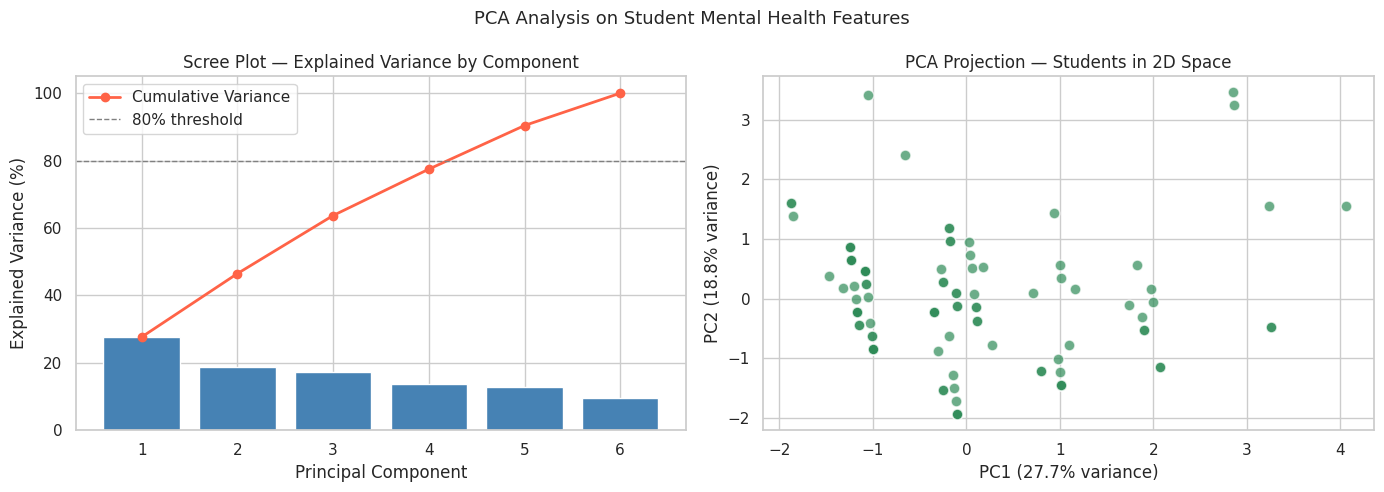


PCA Feature Loadings (PC1 & PC2):
                                                 PC1     PC2
Do you have Depression?                       0.6041  0.0350
Do you have Anxiety?                          0.4243 -0.5141
Do you have Panic attack?                     0.4213  0.3357
Did you seek any specialist for a treatment?  0.4930  0.3285
Age                                          -0.0380  0.5398
CGPA_numeric                                  0.1820 -0.4718


In [9]:
# ─────────────────────────────────────────────
# Task 5: Apply PCA and Interpret Explained Variance
# ─────────────────────────────────────────────

print("=" * 55)
print("TASK 5: PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("=" * 55)

# Encode all Yes/No columns as binary (1/0)
binary_cols = [
    "Do you have Depression?",
    "Do you have Anxiety?",
    "Do you have Panic attack?",
    "Did you seek any specialist for a treatment?"
]

df_pca = df[binary_cols + ["Age", "CGPA_numeric"]].copy()

for col in binary_cols:
    df_pca[col] = df_pca[col].map({"Yes": 1, "No": 0})

# Drop any rows with NaN after encoding
df_pca.dropna(inplace=True)

print(f"\nFeatures used for PCA: {list(df_pca.columns)}")
print(f"Shape after encoding: {df_pca.shape}")

# Standardize before PCA (required)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# ── Apply PCA with all components ─────────────
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\nExplained Variance per Component:")
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance), 1):
    print(f"   PC{i}: {ev*100:.2f}%   |   Cumulative: {cv*100:.2f}%")

# ── Apply PCA with 2 components for visualization ─
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"\n✅ Variance explained by PC1 + PC2: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

# ── Plot 1: Scree Plot ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained_variance)+1), explained_variance * 100,
            color="steelblue", edgecolor="white")
axes[0].plot(range(1, len(cumulative_variance)+1), cumulative_variance * 100,
             color="tomato", marker="o", linewidth=2, label="Cumulative Variance")
axes[0].axhline(y=80, color="gray", linestyle="--", linewidth=1, label="80% threshold")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot — Explained Variance by Component")
axes[0].set_xticks(range(1, len(explained_variance)+1))
axes[0].legend()

# ── Plot 2: PCA 2D Scatter ─────────────────────
axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                alpha=0.7, color="seagreen", edgecolors="white", s=60)
axes[1].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[1].set_title("PCA Projection — Students in 2D Space")

plt.suptitle("PCA Analysis on Student Mental Health Features", fontsize=13)
plt.tight_layout()
plt.show()

# ── PCA Loadings ───────────────────────────────
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1", "PC2"],
    index=df_pca.columns
)
print("\nPCA Feature Loadings (PC1 & PC2):")
print(loadings.round(4))

### 📝 Task 5 — PCA Interpretation

**What is PCA?**  
Principal Component Analysis (PCA) is a dimensionality reduction technique. It transforms the original features into a new set of uncorrelated variables called **Principal Components (PCs)**, ordered by the amount of variance they explain.

---

**Features Used:**  
`Depression`, `Anxiety`, `Panic Attack`, `Sought Treatment`, `Age`, `CGPA_numeric` — 6 features total, 101 students.

---

**Explained Variance per Component:**

| Component | Variance Explained | Cumulative Variance |
|-----------|--------------------|---------------------|
| PC1       | 27.66%             | 27.66%              |
| PC2       | 18.81%             | 46.47%              |
| PC3       | 17.23%             | 63.70%              |
| PC4       | 13.76%             | 77.46%              |
| PC5       | 12.94%             | 90.40%              |
| PC6       |  9.60%             | 100.00%             |

---

**Key Observations:**

- **PC1 (27.66%)** is the most informative component. Looking at the feature loadings, it has strong positive weights for `Depression (0.6041)`, `Sought Treatment (0.4930)`, `Anxiety (0.4243)`, and `Panic Attack (0.4213)`. This means PC1 primarily captures the **overall mental health burden** — students who score high on PC1 tend to report multiple mental health issues and are more likely to have sought help.

- **PC2 (18.81%)** captures a different pattern. It has a strong positive loading for `Age (0.5398)` and a strong **negative** loading for `Anxiety (−0.5141)`. This suggests PC2 separates students by **age and anxiety patterns** — older students may show different anxiety profiles than younger ones.

- **PC1 + PC2 together explain 46.47%** of the total variance, meaning a 2D projection retains nearly half the information from 6 original features.

- To reach the **80% variance threshold**, we need **4 principal components** (cumulative: 77.46% at PC4, crossed at PC5 with 90.40%).

- The **scree plot** shows a gradual decline with no sharp elbow, indicating that variance is spread relatively evenly across components — typical for survey data where no single feature dominates.

- The **2D scatter plot** shows that students are spread across the PC1–PC2 space with some clustering toward the left (negative PC1), representing students with fewer mental health issues.

---

**Conclusion:**  
PCA successfully reduced 6 features into principal components. PC1 effectively summarizes the mental health burden (depression, anxiety, panic attacks, and treatment-seeking), while PC2 highlights age-related anxiety differences. Retaining 4–5 components would preserve over 80–90% of the dataset's information, making PCA a useful tool for dimensionality reduction before applying machine learning models.